# General Libraries

In [706]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Data

In [707]:
df = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\2. Interviews & Surveys\3. Quantitative Survey\Tourism surveyEncuesta de turismo.xlsx")

In [708]:
# Leave only needed columns
df = df.iloc[:,6:]

In [709]:
df.columns = [
    "travel_attributes_importance",
    "att_central_accommodation",
    "att_accommodation_services",
    "define_accommodation",
    "accommodation_search",
    "att_less_crowded_destinations",
    "less_crowded_willingness",
    "extra_travel_time",
    "att_heritage_ambience",
    "att_attractions_density",
    "att_guided_tours_flexibility",
    "city_tour_interest",
    "city_tour_type",
    "architectural_interest",
    "att_local_restaurants_diversity",
    "eating_preference",
    "restaurant_choice",
    "att_natural_areas_proximity",
    "natural_environment_type",
    "att_tourist_info_availability",
    "att_museums_art_availability",
    "too_cheap",
    "cheap",
    "expensive",
    "too_expensive",
    "visited_ascoli",
    "recommend_ascoli",
    "ascoli_likelihood",
    "heard_ascoli",
    "ascoli_attractiveness",
    "age_group",
    "gender",
    "residence",
    "occupation"]

In [710]:
# Replace some cases
df['city_tour_type'] = df['city_tour_type'].replace({"free tours": "Guided walking tour (Tour guiado a pie)"})

df['occupation'] = df['occupation'].replace({"Justicia": "Employed (Empleado/a)"})

In [711]:
df.head(2)

,travel_attributes_importance,att_central_accommodation,att_accommodation_services,define_accommodation,accommodation_search,att_less_crowded_destinations,less_crowded_willingness,extra_travel_time,att_heritage_ambience,att_attractions_density,...,too_expensive,visited_ascoli,recommend_ascoli,ascoli_likelihood,heard_ascoli,ascoli_attractiveness,age_group,gender,residence,occupation
0,Diversity of authentic local restaurants (Dive...,Agree (De acuerdo),Agree (De acuerdo),…book at the last minute (reservar a último mo...,Online platforms as Booking (En plataformas on...,Strongly diasgree (Totalmente en desacuerdo),2,1–2 hours (1-2 horas),Agree (De acuerdo),Disagree (En desacuerdo),...,250,No,NaN,10.0,No,7,18-25,Female (Femenino),South America (América del Sur),Employed (Empleado/a)
1,Heritage ambience of the historic center (Ambi...,Neutral,Neutral,…book in advance during the planning phase (re...,Online platforms as Booking (En plataformas on...,Neutral,3,3–4 hours (3-4 horas),Neutral,Neutral,...,100,No,NaN,5.0,Yes (Si),6,18-25,Male (Masculino),South America (América del Sur),Employed (Empleado/a)


# Ranking Consistency

In [712]:
def attributes(row):
    attribute = [a.strip() for a in row.split(";") if a.strip()]
    return {a: i+1 for i, a in enumerate(attribute)}

df_attributes = df["travel_attributes_importance"].apply(attributes)

df_attributes = pd.DataFrame(df_attributes.tolist())

df_attributes.columns = [
    "Diversity of authentic local restaurants",
    "Density of touristic attractions within walking distance",
    "City located outside major tourist circuits",
    "Availability of tourist information, both digital and on-site",
    "Availability of centrally located accommodation",
    "Availability of museums and art venues",
    "Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",
    "Heritage ambience of the historic center",
    "Proximity to natural areas or outdoor routes",
    "Flexible scheduling of guided tours"]

df_attributes

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
0,1,2,3,4,5,6,7,8,9,10
1,2,10,6,8,4,3,9,1,5,7
2,5,6,10,9,2,4,7,1,3,8
3,10,2,7,8,3,5,4,1,6,9
4,1,3,5,6,2,9,7,4,8,10
...,...,...,...,...,...,...,...,...,...,...
117,5,9,10,4,6,3,7,1,2,8
118,6,4,7,9,8,2,10,1,5,3
119,1,8,10,7,3,2,5,4,6,9
120,3,9,6,5,2,4,1,7,8,10


In [713]:
df_attributes.to_excel('attributes_for_clustering.xlsx')

In [714]:
df_inverted = df_attributes.copy()
df_inverted = 11 - df_inverted

In [715]:
df_inverted.head(3)

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
0,10,9,8,7,6,5,4,3,2,1
1,9,1,5,3,7,8,2,10,6,4
2,6,5,1,2,9,7,4,10,8,3


In [716]:
df_ranking_scaled = 1 + (df_inverted - 1) * (4 / 9)

In [717]:
df_ranking_scaled.head(3)

,Diversity of authentic local restaurants,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
0,5.000000,4.555556,4.111111,3.666667,3.222222,2.777778,2.333333,1.888889,1.444444,1.000000
1,4.555556,1.000000,2.777778,1.888889,3.666667,4.111111,1.444444,5.000000,3.222222,2.333333
2,3.222222,2.777778,1.000000,1.444444,4.555556,3.666667,2.333333,5.000000,4.111111,1.888889


In [718]:
# Likert questions
cols = [
    "att_central_accommodation",
    "att_accommodation_services",
    "att_less_crowded_destinations",
    "att_heritage_ambience",
    "att_attractions_density",
    "att_guided_tours_flexibility",
    "att_local_restaurants_diversity",
    "att_natural_areas_proximity",
    "att_tourist_info_availability",
    "att_museums_art_availability"
]

df_likert = df[cols]

value_map = {
    "Strongly diasgree (Totalmente en desacuerdo)": 1,
    "Disagree (En desacuerdo)": 2,
    "Neutral": 3,
    "Agree (De acuerdo)": 4,
    "Strongly agree (Totalmente de acuerdo)": 5
}

df_likert[cols] = df_likert[cols].replace(value_map)

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\1243115299.py:25: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_likert[cols] = df_likert[cols].replace(value_map)
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\1243115299.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_likert[cols] = df_likert[cols].replace(value_map)


In [719]:
# Order columns according to attributes dataframe

df_likert = df_likert[["att_local_restaurants_diversity", "att_attractions_density", "att_less_crowded_destinations",
                       "att_tourist_info_availability", "att_central_accommodation", "att_museums_art_availability",
                       "att_accommodation_services", "att_heritage_ambience", "att_natural_areas_proximity",
                       "att_guided_tours_flexibility"]]

In [720]:
df_likert.head(3)

,att_local_restaurants_diversity,att_attractions_density,att_less_crowded_destinations,att_tourist_info_availability,att_central_accommodation,att_museums_art_availability,att_accommodation_services,att_heritage_ambience,att_natural_areas_proximity,att_guided_tours_flexibility
0,4,2,1,4,4,1,4,4,4,2
1,3,3,3,3,3,3,3,3,3,3
2,2,2,4,1,3,3,3,5,5,1


In [721]:
from scipy.stats import spearmanr

corrs = []
for i in range(len(df_ranking_scaled.columns)):
    x = df_ranking_scaled.iloc[:, i]
    y = df_likert.iloc[:, i]
    
    # Spearman correlation and p-value
    rho, p = spearmanr(x, y)
    
    corrs.append({
        'Attribute': df_ranking_scaled.columns[i],
        'Spearman_rho': rho,
        'p_value': p
    })

result = pd.DataFrame(corrs)

def sig_label(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return ''

result['Significance'] = result['p_value'].apply(sig_label)

result['Spearman_rho'] = result['Spearman_rho'].round(3)
result['p_value'] = result['p_value'].round(4)

result

,Attribute,Spearman_rho,p_value,Significance
0,Diversity of authentic local restaurants,0.435,0.0000,****
1,Density of touristic attractions within walkin...,0.470,0.0000,****
2,City located outside major tourist circuits,0.185,0.0411,*
3,"Availability of tourist information, both digi...",0.571,0.0000,****
4,Availability of centrally located accommodation,0.401,0.0000,****
5,Availability of museums and art venues,0.614,0.0000,****
6,"Accommodation services, such as flexible cance...",0.447,0.0000,****
7,Heritage ambience of the historic center,0.533,0.0000,****
8,Proximity to natural areas or outdoor routes,0.526,0.0000,****
9,Flexible scheduling of guided tours,0.453,0.0000,****


Spearman's rank correlation coefficient or Spearman's ρ is a number ranging from -1 to 1 that indicates how strongly two sets of ranks are correlated.

In [722]:
likert_counts = df_likert.apply(lambda x: x.value_counts()).fillna(0).astype(int)
likert_counts = likert_counts.reindex([1, 2, 3, 4, 5])
likert_counts_T = likert_counts.T

def highlight_top2(s):
    is_top2 = s >= s.nlargest(2).min()
    return ['background-color: green' if v else '' for v in is_top2]

likert_counts_T.style.apply(highlight_top2, axis=1)

,1,2,3,4,5
att_local_restaurants_diversity,0,9,25,45,43
att_attractions_density,3,7,28,52,32
att_less_crowded_destinations,4,6,36,52,24
att_tourist_info_availability,3,11,28,52,28
att_central_accommodation,4,5,16,66,31
att_museums_art_availability,7,10,40,48,17
att_accommodation_services,4,5,27,56,30
att_heritage_ambience,4,6,20,52,40
att_natural_areas_proximity,1,6,40,53,22
att_guided_tours_flexibility,17,15,36,36,18


# K-Mean

## Libraries

In [723]:
# Clustering Algorithms
from sklearn.cluster import KMeans
from scipy.cluster.hierarchy import linkage, dendrogram

# Cluster Evaluation
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score, calinski_harabasz_score, adjusted_rand_score
from scipy.stats import kendalltau
from scipy.spatial.distance import squareform

# Visualization
from yellowbrick.cluster import KElbowVisualizer
from sklearn.manifold import TSNE

## Defining Optimal K

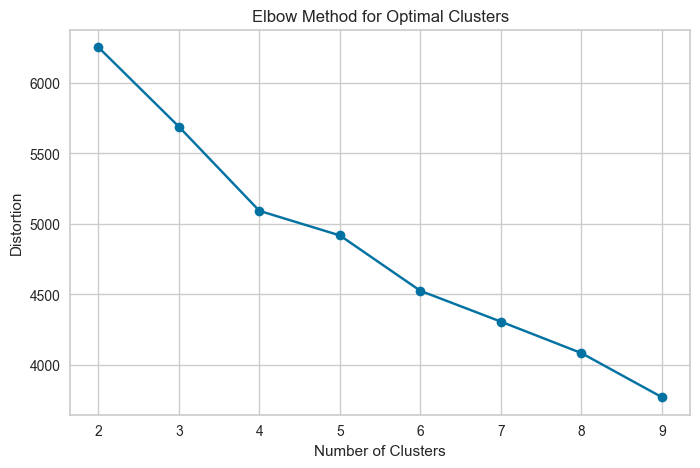

In [724]:
# Elbow
distortions = []
K = range(2, 10)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_attributes)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, distortions, marker='o')
plt.title('Elbow Method for Optimal Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Distortion')
plt.show()

Although it is not too clear, there is a change in the slope in the point 5.

Nevertheless, more models will be used to check this k.

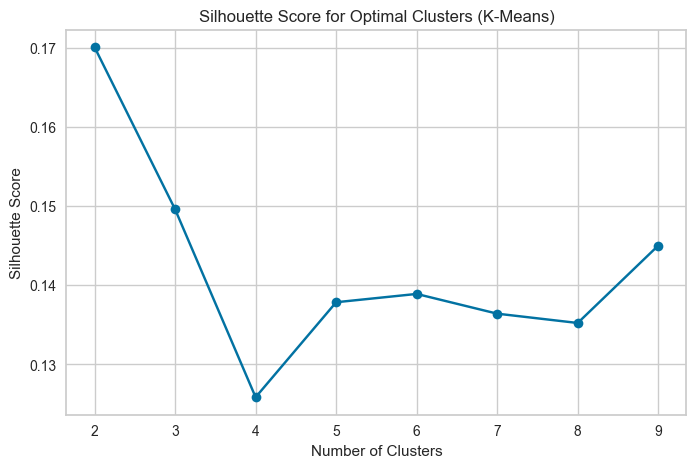

In [725]:
# Silhouette
K = range(2, 10)
silhouette_scores = []

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_attributes)
    score = silhouette_score(df_attributes, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(K, silhouette_scores, marker='o')
plt.title('Silhouette Score for Optimal Clusters (K-Means)')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

For n_clusters = 2 The average silhouette_score is : 0.17006970327423077
For n_clusters = 3 The average silhouette_score is : 0.1618379805202896
For n_clusters = 4 The average silhouette_score is : 0.1483518503586441
For n_clusters = 5 The average silhouette_score is : 0.14055803022916374
For n_clusters = 6 The average silhouette_score is : 0.13546549977973993


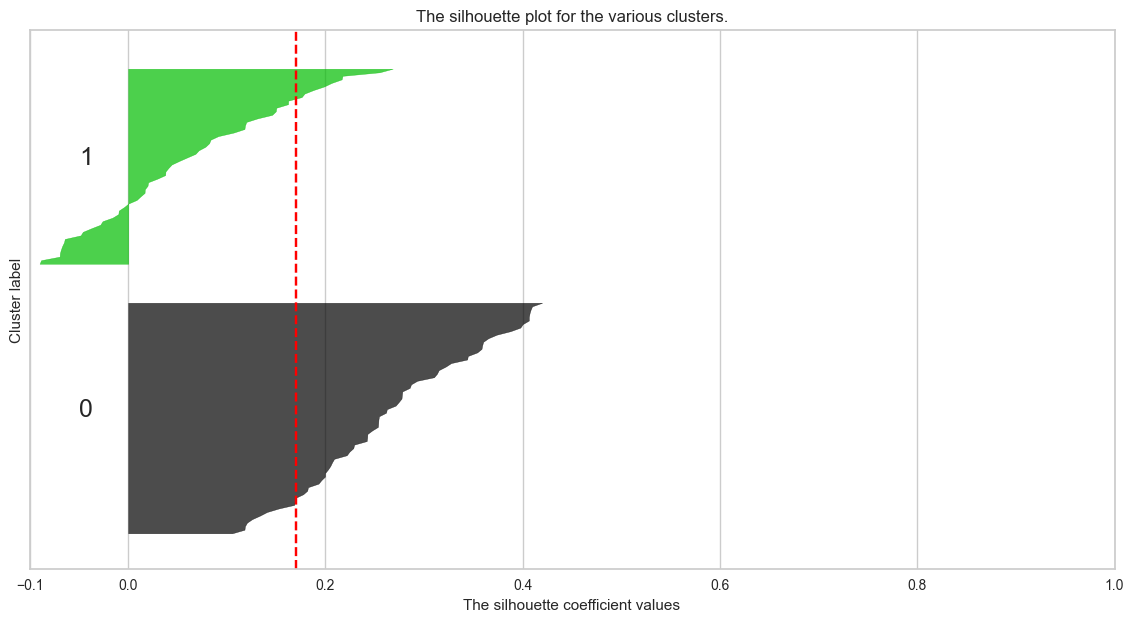

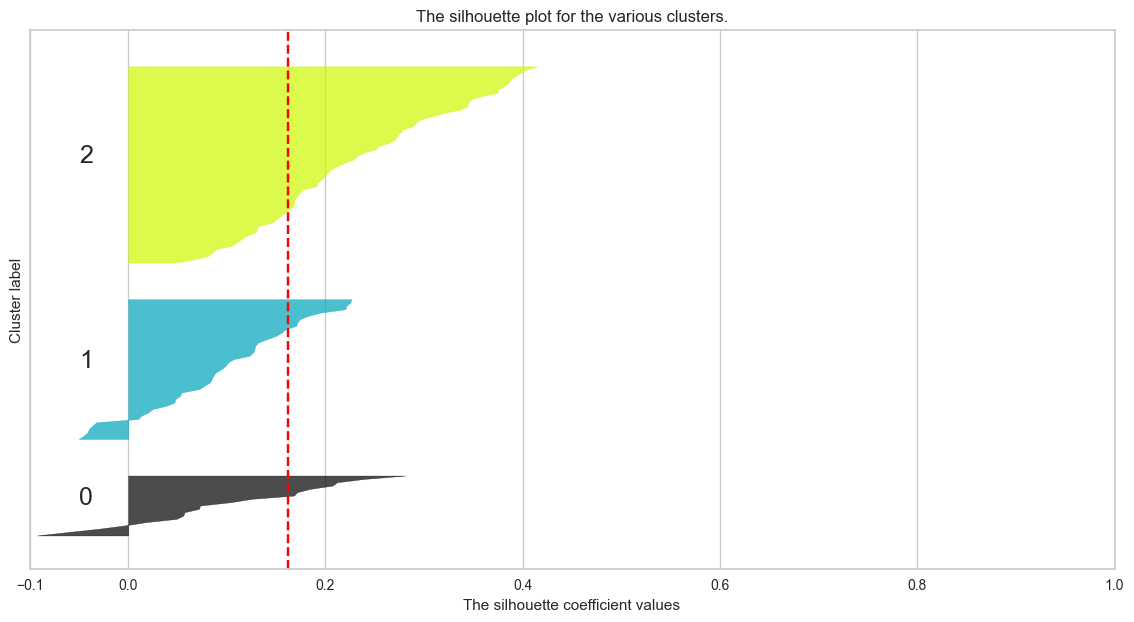

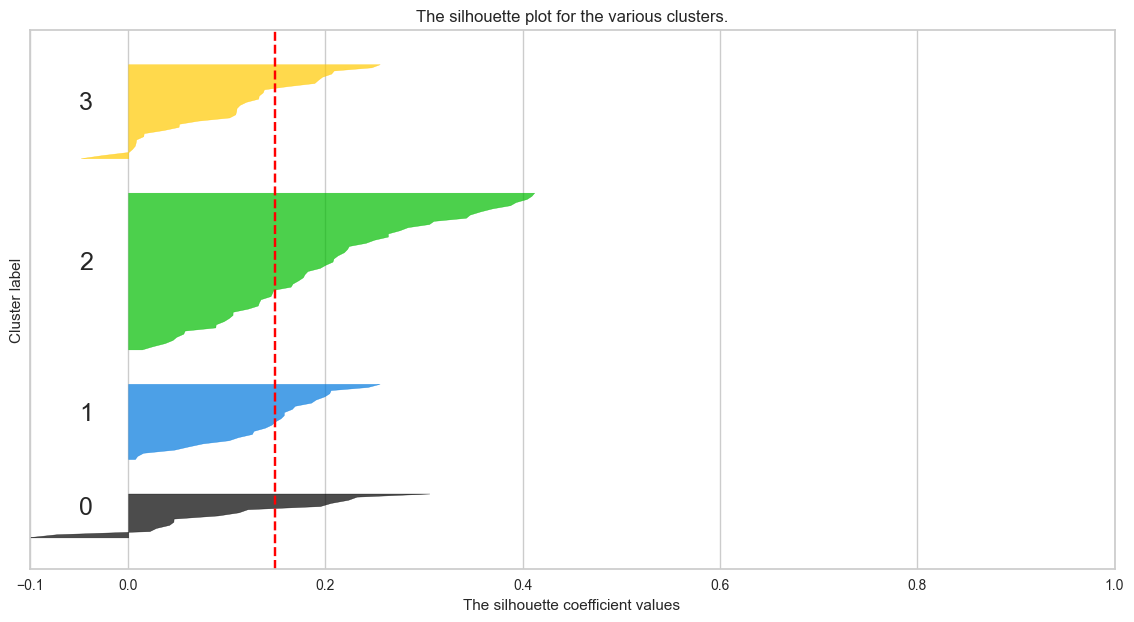

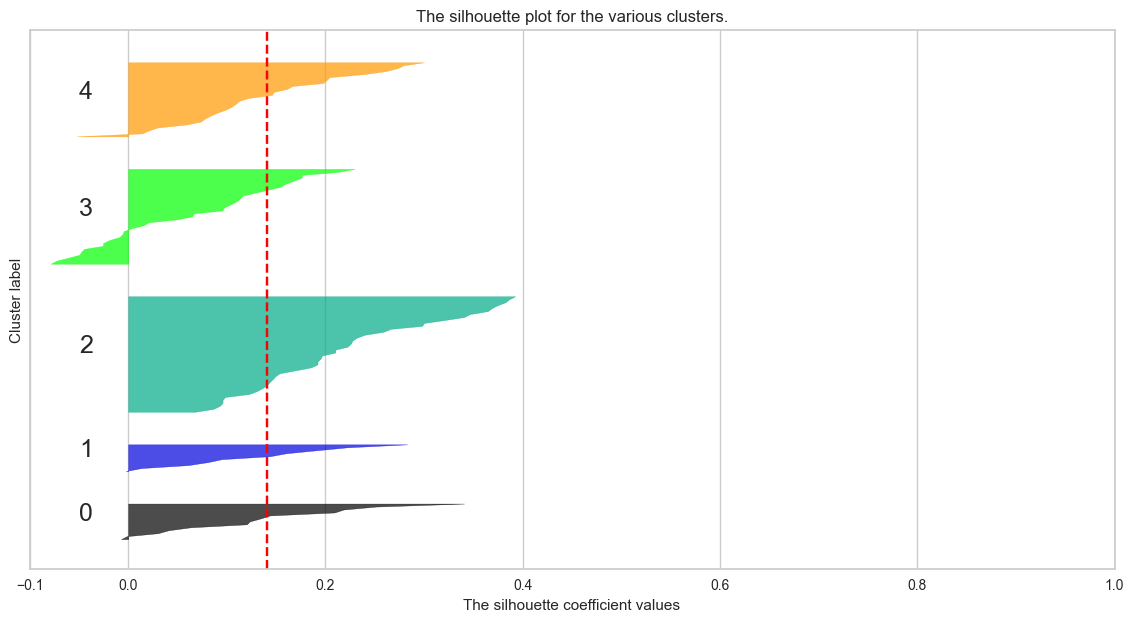

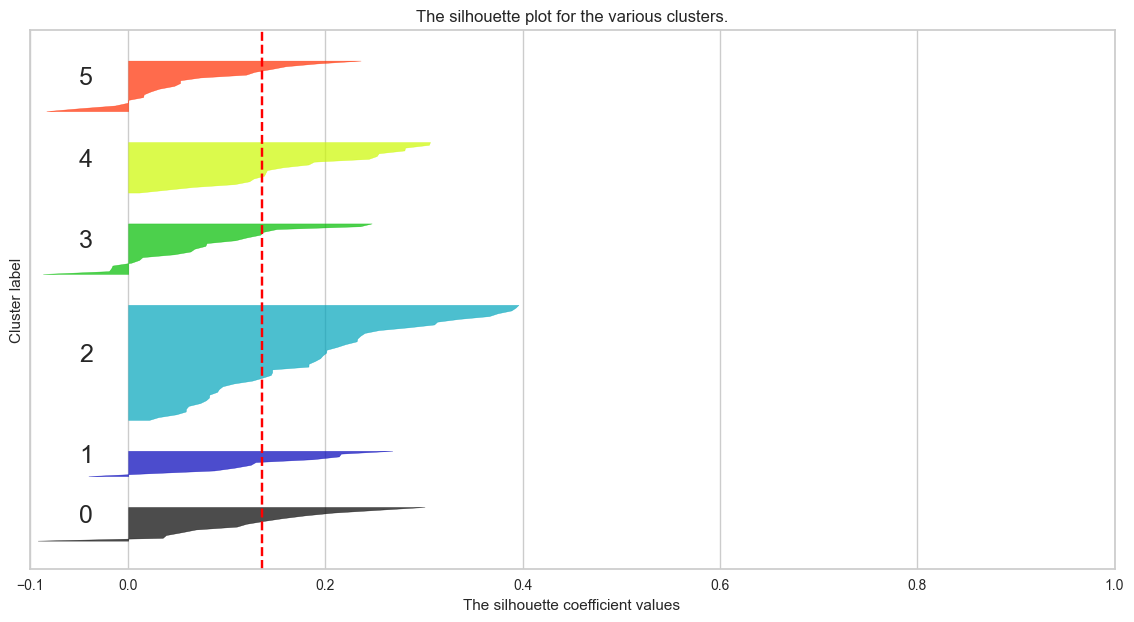

In [726]:
import matplotlib.cm as cm

X = df_attributes.to_numpy()
range_n_clusters = [2, 3, 4, 5, 6]

for n_clusters in range_n_clusters:
    fig, ax = plt.subplots()
    fig.set_size_inches(14, 7)

    # Silhouette plot
    # The silhouette coefficient can range from -1, 1 but in this example all
    # lie within [-0.1, 1]
    ax.set_xlim([-0.1, 1])
    # The (n_clusters+1)*10 is for inserting blank space between silhouette
    # plots of individual clusters, to demarcate them clearly.
    ax.set_ylim([0, len(X) + (n_clusters + 1) * 10])

    # Initialize the clusterer with n_clusters value and a random generator
    # seed of 10 for reproducibility.
    clusterer = KMeans(n_clusters=n_clusters,random_state=10)
    cluster_labels = clusterer.fit_predict(X)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(X, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )

    # Compute the silhouette scores for each sample
    sample_silhouette_values = silhouette_samples(X, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        # Aggregate the silhouette scores for samples belonging to
        # cluster i, and sort them
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )

        # Label the silhouette plots with their cluster numbers at the middle
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

        # Compute the new y_lower for next plot
        y_lower = y_upper + 10  # 10 for the 0 samples

    ax.set_title("The silhouette plot for the various clusters.")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")

    # The vertical line for average silhouette score of all the values
    ax.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax.set_yticks([])  # Clear the yaxis labels / ticks
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

In [727]:
optimal_k = [2, 3, 4, 5, 6, 7, 8, 9, 10]

for k in optimal_k:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(df_attributes)

    db_index = davies_bouldin_score(df_attributes, cluster_labels)
    print(f"Davies-Bouldin Index for k={k}: {db_index}")

Davies-Bouldin Index for k=2: 2.127252949751706
Davies-Bouldin Index for k=3: 1.8767971087531636
Davies-Bouldin Index for k=4: 1.9217229943493326
Davies-Bouldin Index for k=5: 1.9928999232570874
Davies-Bouldin Index for k=6: 1.8344289727399994
Davies-Bouldin Index for k=7: 1.743015057814757
Davies-Bouldin Index for k=8: 1.7618909288644762
Davies-Bouldin Index for k=9: 1.6791749918634475
Davies-Bouldin Index for k=10: 1.619932838882015


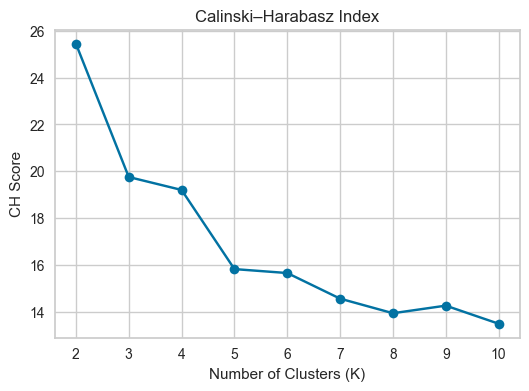

In [728]:
K_range = range(2, 11)
ch_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)

    ch = calinski_harabasz_score(X, labels)
    ch_scores.append(ch)

plt.figure(figsize=(6,4))
plt.plot(K_range, ch_scores, marker='o')
plt.title('Calinski–Harabasz Index')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('CH Score')
plt.grid(True)
plt.show()

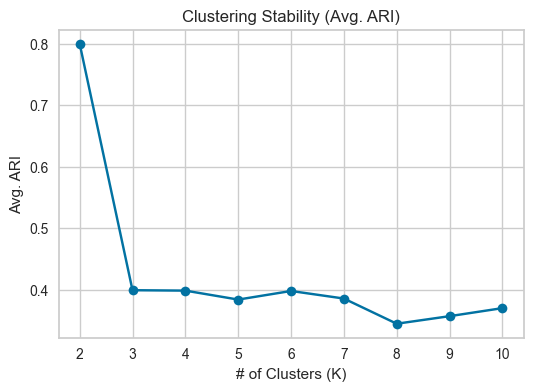

In [729]:
K_range = range(2, 11)
n_runs = 5  # repetition of clustering by K

mean_ari_scores = []

for k in K_range:
    labels_list = []

    # Several runs by K
    for seed in range(n_runs):
        kmeans = KMeans(n_clusters=k, random_state=seed)
        labels = kmeans.fit_predict(X)
        labels_list.append(labels)
    
    # Average ARI
    ari_scores = []
    for i in range(n_runs):
        for j in range(i + 1, n_runs):
            ari = adjusted_rand_score(labels_list[i], labels_list[j])
            ari_scores.append(ari)
    
    mean_ari = np.mean(ari_scores)
    mean_ari_scores.append(mean_ari)

plt.figure(figsize=(6,4))
plt.plot(K_range, mean_ari_scores, marker='o')
plt.title('Clustering Stability (Avg. ARI)')
plt.xlabel('# of Clusters (K)')
plt.ylabel('Avg. ARI')
plt.grid(True)
plt.show()

# Clustering

After some research, a better way to find optimal K is to use Gower distance + K-medoids, as we are using ordinal data.
For technical reasons, the analysis of optimal K was done in Google Colab, and from now onwards the .xlsx obtained is used

In [730]:
df_attributes = pd.read_excel(r"C:\Users\franc\Documents\GitHub\DSE_thesis\Material\2. Interviews & Surveys\3. Quantitative Survey\four_clusters.xlsx")

In [731]:
df_attributes['cluster'] = df_attributes['cluster'].replace({0: 1, 1: 2, 2: 3, 3: 4})

In [732]:
df_clustering = df_attributes

In [733]:
df_clustering.head(2)

,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours,cluster
0,2,3,4,5,6,7,8,9,10,2
1,10,6,8,4,3,9,1,5,7,4


In [734]:
#Segment sizes:

df_clustering_sizes = pd.DataFrame(df_clustering.groupby("cluster").size(),columns=["Size"]).T
df_clustering_sizes.insert(0,"Population",len(df_attributes))
df_clustering_sizes.loc["%"] = df_clustering_sizes.iloc[0].div(df_clustering_sizes.iloc[0,0]).mul(100).astype(int)
df_clustering_sizes

cluster,Population,1,2,3,4
Size,122,28,23,32,39
%,100,22,18,26,31


In [735]:
# Means of segmentation variables by segment:

from scipy import stats

df_clustering_Means = df_clustering.groupby("cluster").mean().T
df_clustering_Means.insert(0,"Population",df_clustering.drop(columns="cluster").mean())

X = df_clustering.copy()

def style_cols(col):
    if col.name == "Population":
        return ["background-color: #616161; color: white"] * len(col)

    segment = X[X["cluster"] == col.name]
    rest_pop = X[X["cluster"] != col.name]

    colors = []
    for var_name, var_segment_mean in col.items():
        if var_name not in X.columns:
            colors.append("background-color: #424242; color: white")
            continue

        t_stat, p_value = stats.ttest_ind(
            segment[var_name],
            rest_pop[var_name],
            equal_var=False,
            nan_policy="omit"
        )

        if p_value < 0.05:
            color = "#00C853" if var_segment_mean > rest_pop[var_name].mean() else "#D50000"
        elif p_value < 0.1:
            color = "#69F0AE" if var_segment_mean > rest_pop[var_name].mean() else "#FF8A80"
        else:
            color = "#424242"
        
        colors.append(f"background-color: {color}; color: white;")

    return colors

df_clustering_Means.style.apply(style_cols, axis=0).format("{:.2f}")

cluster,Population,1,2,3,4
Density of touristic attractions within walking distance,5.89,5.07,4.17,5.16,8.08
City located outside major tourist circuits,7.12,7.68,8.43,7.72,5.46
"Availability of tourist information, both digital and on-site",6.43,8.18,4.78,5.38,7.00
Availability of centrally located accommodation,4.26,4.50,3.61,3.69,4.95
Availability of museums and art venues,5.04,3.54,6.13,6.69,4.13
"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",5.68,6.21,6.43,2.47,7.49
Heritage ambience of the historic center,3.21,2.00,3.04,5.69,2.15
Proximity to natural areas or outdoor routes,5.34,5.39,7.22,5.84,3.79
Flexible scheduling of guided tours,8.16,9.00,6.70,7.53,8.92


In [736]:
from pca import pca

features = df_clustering.drop(columns="cluster")
segments = df_clustering.cluster

general_pca = pca()

results = general_pca.fit_transform(features)

results.keys()

[23-10-2025 10:53:28] [pca.pca] [INFO] Extracting column labels from dataframe.
[23-10-2025 10:53:28] [pca.pca] [INFO] Extracting row labels from dataframe.
[23-10-2025 10:53:28] [pca.pca] [INFO] PCA reduction performed to capture 95.0% explained variance using 9 columns of the input data.
[23-10-2025 10:53:28] [pca.pca] [INFO] Fit using PCA.
[23-10-2025 10:53:28] [pca.pca] [INFO] Compute loadings and PCs.
[23-10-2025 10:53:28] [pca.pca] [INFO] Compute explained variance.
[23-10-2025 10:53:28] [pca.pca] [INFO] Number of components is 8 that covers 95.00% explained variance.
[23-10-2025 10:53:28] [pca.pca] [INFO] The PCA reduction is performed on the 9 columns of the input dataframe.
[23-10-2025 10:53:28] [pca.pca] [INFO] Fit using PCA.
[23-10-2025 10:53:28] [pca.pca] [INFO] Compute loadings and PCs.
[23-10-2025 10:53:28] [pca.pca] [INFO] Outlier detection using Hotelling T2 test with alpha=[0.05] and n_components=[8]
[23-10-2025 10:53:28] [pca.pca] [INFO] Multiple test correction appli

dict_keys(['loadings', 'PC', 'explained_var', 'variance_ratio', 'model', 'scaler', 'pcp', 'topfeat', 'outliers', 'outliers_params'])

In [737]:
var_exp = general_pca.results['variance_ratio'] * 100
var_exp_df = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(len(var_exp))],
    'Explained Variance (%)': var_exp
})

print(var_exp_df.round(2))

  Component  Explained Variance (%)
0       PC1                   25.56
1       PC2                   20.56
2       PC3                   15.15
3       PC4                   10.70
4       PC5                    9.01
5       PC6                    7.45
6       PC7                    5.81
7       PC8                    4.89
8       PC9                    0.86


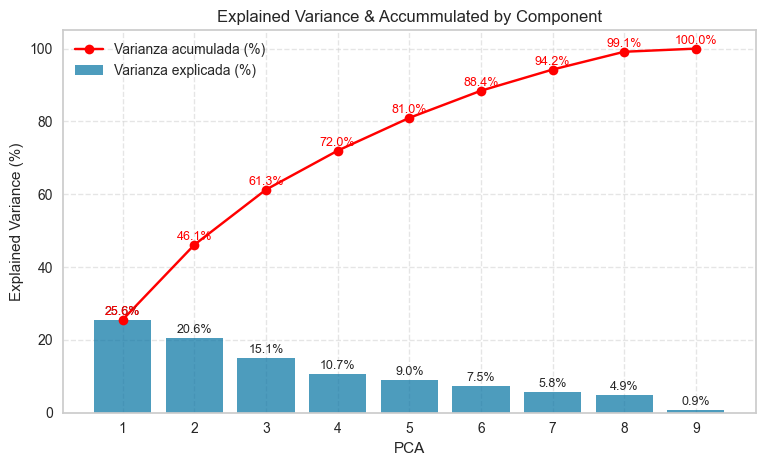

In [738]:
acum_var_exp = np.cumsum(var_exp)
components = np.arange(1, len(var_exp) + 1)

plt.figure(figsize=(8, 5))

plt.bar(components, var_exp, alpha=0.7, label='Varianza explicada (%)')

for i, v in enumerate(var_exp):
    plt.text(i + 1, v + 0.5, f"{v:.1f}%", ha='center', va='bottom', fontsize=9)

plt.plot(components, acum_var_exp, marker='o', color='red', label='Varianza acumulada (%)')

for i, v in enumerate(acum_var_exp):
    plt.text(i + 1, v + 0.5, f"{v:.1f}%", color='red', ha='center', va='bottom', fontsize=9)

plt.title('Explained Variance & Accummulated by Component')
plt.xlabel('PCA')
plt.ylabel('Explained Variance (%)')
plt.xticks(components)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

In [739]:
general_pca.results['loadings']

,Density of touristic attractions within walking distance,City located outside major tourist circuits,"Availability of tourist information, both digital and on-site",Availability of centrally located accommodation,Availability of museums and art venues,"Accommodation services, such as flexible cancellation, digital check-in, amenities, etc.",Heritage ambience of the historic center,Proximity to natural areas or outdoor routes,Flexible scheduling of guided tours
PC1,0.319594,-0.342911,0.281723,0.255384,-0.348982,0.426902,-0.370684,-0.354554,0.261788
PC2,0.605381,-0.377830,-0.276267,0.077386,0.185814,-0.327744,0.423188,-0.294212,-0.029244
PC3,0.552581,0.252241,0.260664,-0.450689,-0.404405,-0.278566,-0.132383,0.317038,-0.027948
PC4,-0.289856,-0.327897,0.672080,-0.092814,0.120025,-0.444067,0.162698,-0.058785,0.326549
PC5,-0.017459,0.145028,0.141651,0.724661,-0.253239,-0.442305,-0.123026,0.030705,-0.397016
PC6,-0.042076,-0.448542,-0.342395,0.191118,-0.155806,-0.103261,-0.112822,0.679137,0.366586
PC7,-0.003472,0.471982,-0.279429,0.105259,-0.000843,-0.329933,-0.195132,-0.303471,0.670099
PC8,-0.196295,0.094662,-0.058388,0.029850,-0.668253,0.138911,0.677223,-0.078639,0.132418


[23-10-2025 10:53:28] [pca.pca] [INFO] Plot PC1 vs PC2 with loadings.
[23-10-2025 10:53:28] [scatterd.scatterd] [INFO] Add density layer
[23-10-2025 10:53:29] [scatterd.scatterd] [INFO] Create scatterplot


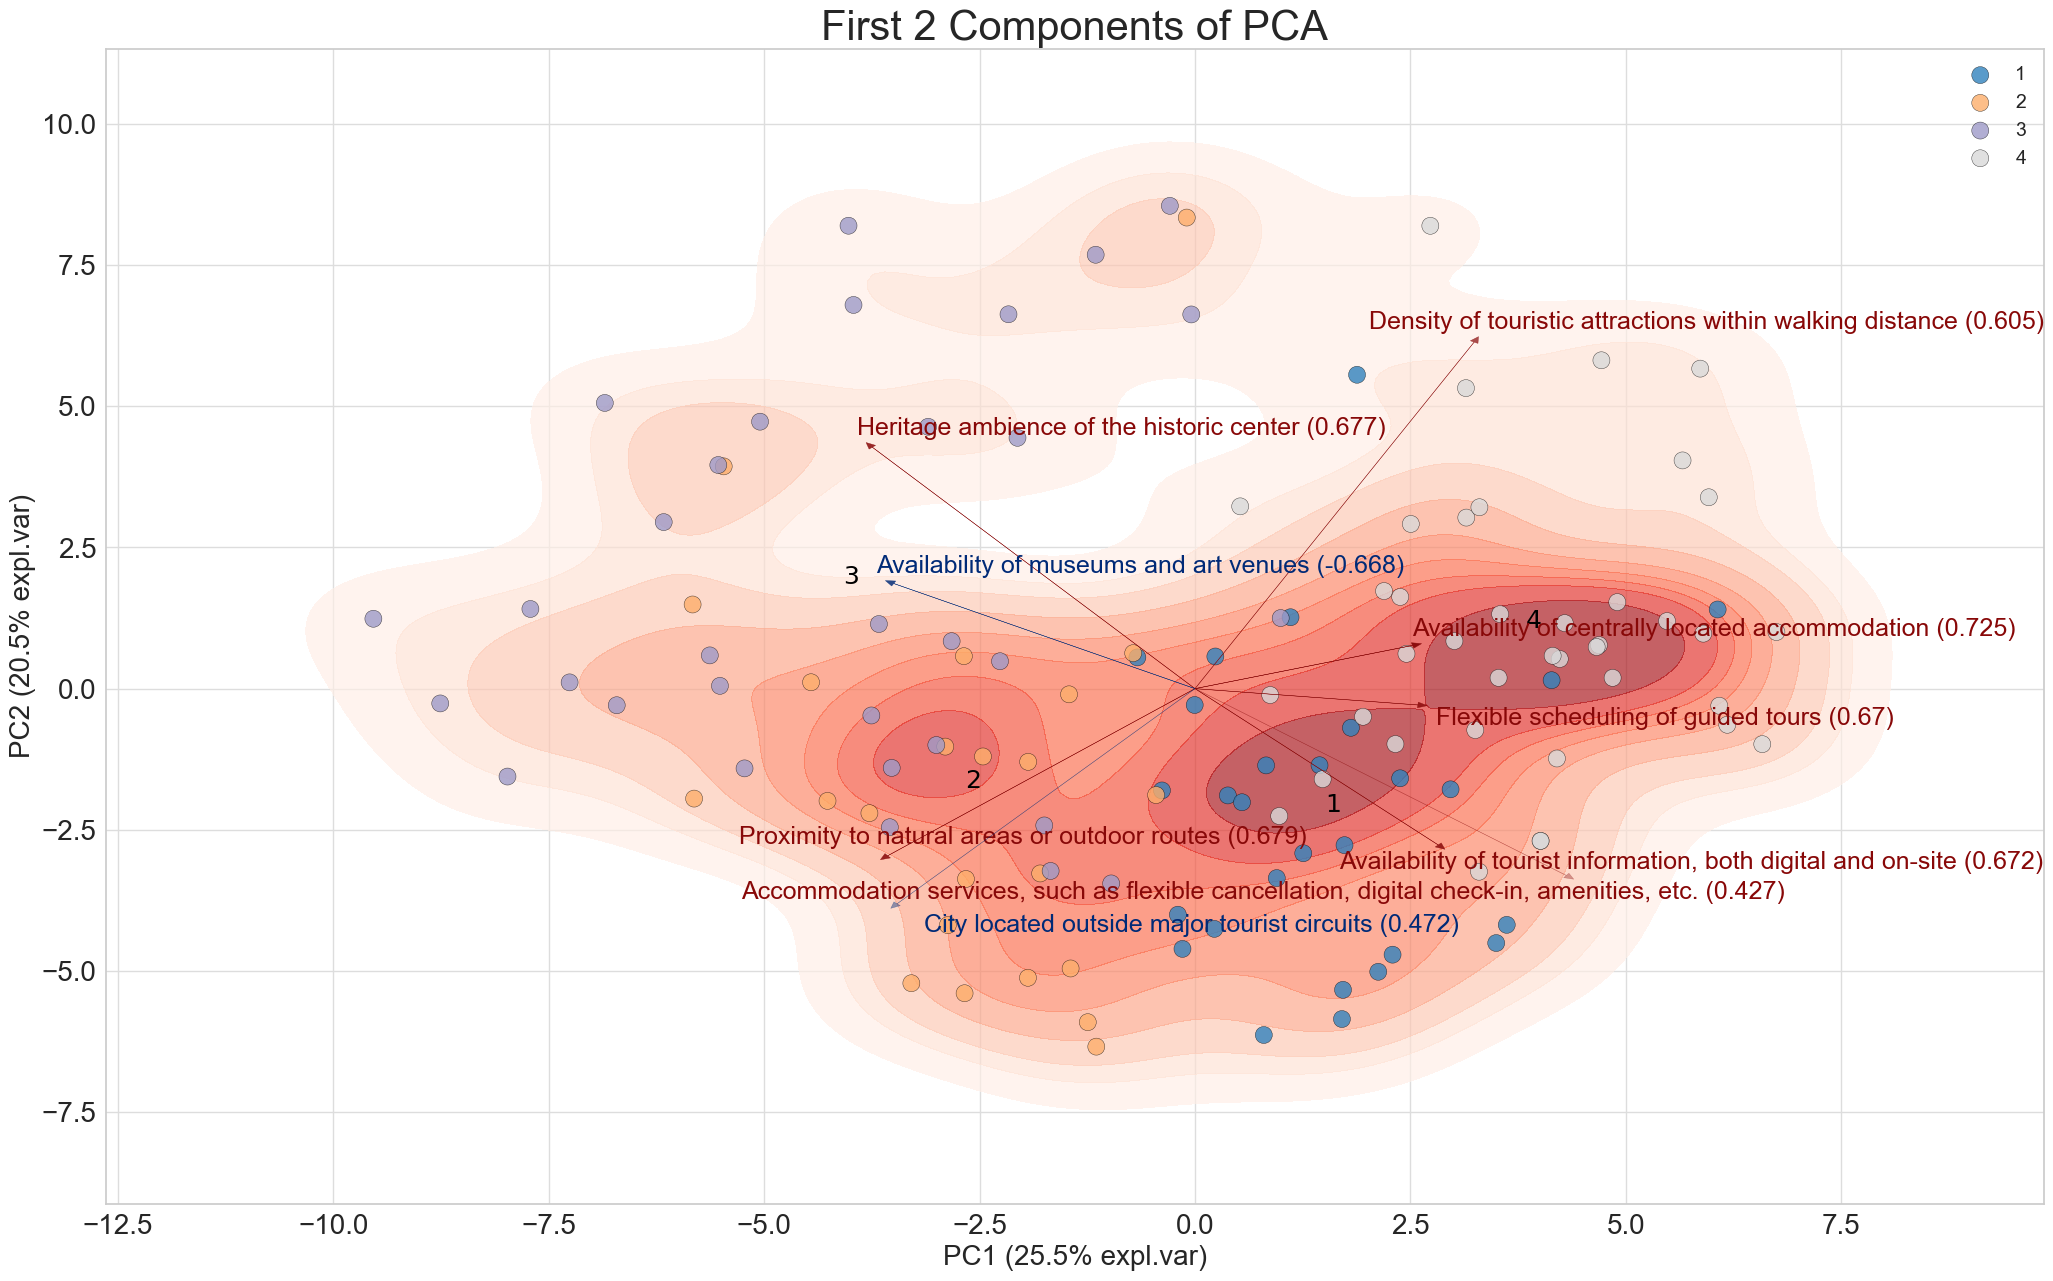

In [740]:
# Biplot usando el PCA ya calculado
fig, ax = general_pca.biplot(
    labels=segments,      # tus etiquetas o clases
    density=True,         # densidad de puntos
    legend=True,          # mostrar leyenda de grupos
    n_feat=10,            # cuántas variables (flechas) mostrar
)

ax.set_title("First 2 Components of PCA", fontsize=30)

plt.show()

The other plots are in Google Colab, to complement these.

# Random Forest

In [741]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

In [742]:
X = df_clustering.drop(columns="cluster")
y = df_clustering.cluster

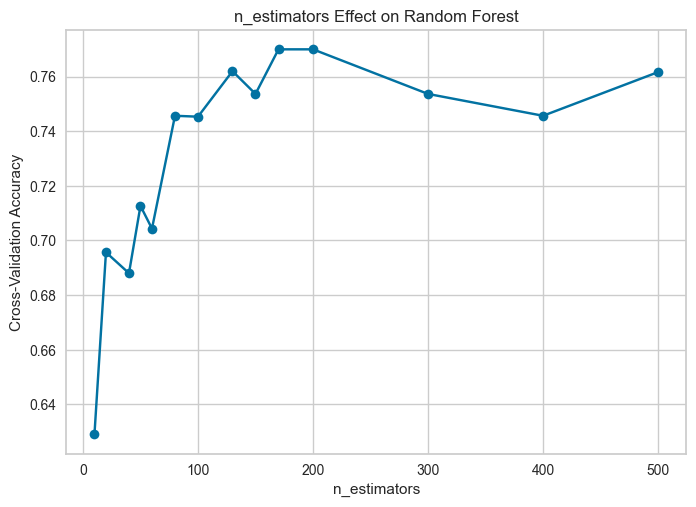

In [743]:
n_list = [10, 20, 40, 50, 60, 80, 100, 130, 150, 170, 200, 300, 400, 500]
scores = []

for n in n_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    score = cross_val_score(rf, X, y, cv=5).mean()
    scores.append(score)

plt.plot(n_list, scores, marker='o')
plt.xlabel("n_estimators")
plt.ylabel("Cross-Validation Accuracy")
plt.title("n_estimators Effect on Random Forest")
plt.show()

In [744]:
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

rf.fit(X, y)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [745]:
importances = pd.DataFrame([rf.feature_importances_], columns=X.columns, index=["Importance"])
importances = importances.T  # Transpose for better readability
importances = importances.sort_values(by="Importance", ascending=False)  # Sort descending
print(importances.round(2))

                                                    Importance
Accommodation services, such as flexible cancel...        0.20
Density of touristic attractions within walking...        0.12
Proximity to natural areas or outdoor routes              0.12
Heritage ambience of the historic center                  0.12
Availability of tourist information, both digit...        0.10
City located outside major tourist circuits               0.10
Availability of museums and art venues                    0.10
Flexible scheduling of guided tours                       0.07
Availability of centrally located accommodation           0.06


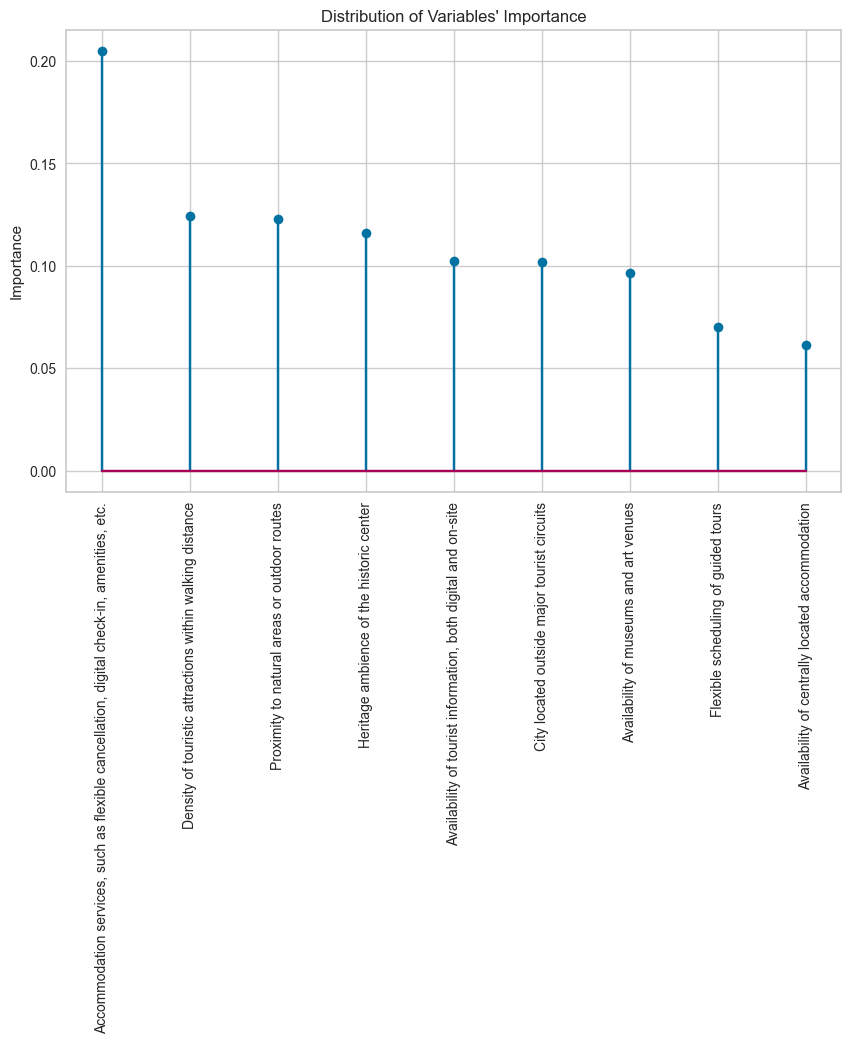

In [746]:
plt.figure(figsize=(10, 6))
plt.stem(importances["Importance"])
plt.xticks(range(len(importances)), importances.index, rotation=90)
plt.title("Distribution of Variables' Importance")
plt.ylabel("Importance")
plt.show()

# Van Westendorp

## Function

In [747]:
# Function to calculate intersection points between two curves
def find_intersection(x1, y1, x2, y2):
    # Interpolate both curves onto a common x-axis grid
    common_x = np.linspace(max(min(x1), min(x2)), min(max(x1), max(x2)), 500)
    y1_interp = np.interp(common_x, x1, y1)
    y2_interp = np.interp(common_x, x2, y2)

    # Calculate the difference between the two curves
    diff = y1_interp - y2_interp
    sign_change = np.where(np.diff(np.sign(diff)))[0]  # Detect zero-crossing

    # Calculate intersections
    intersections = []
    for idx in sign_change:
        x_intersect = np.interp(0, [diff[idx], diff[idx + 1]], [common_x[idx], common_x[idx + 1]])
        y_intersect = np.interp(x_intersect, x1, y1)  # Use one curve for the y-value
        intersections.append((x_intersect, y_intersect))
    return intersections

# Van Westendorp analysis function (no product_name)
def van_westendorp_analysis(df):
    # Extract the relevant columns
    too_cheap = df['too_cheap']
    cheap = df['cheap']
    expensive = df['expensive']
    too_expensive = df['too_expensive']

    # Function to calculate cumulative percentages
    def calculate_cumulative_percent(series, invert=False):
        sorted_series = np.sort(series)
        cum_percent = np.arange(1, len(sorted_series) + 1) / len(sorted_series) * 100
        if invert:
            cum_percent = 100 - cum_percent
        return sorted_series, cum_percent

    # Calculate cumulative percentages
    too_cheap_sorted, too_cheap_cum = calculate_cumulative_percent(too_cheap, invert=True)
    cheap_sorted, cheap_cum = calculate_cumulative_percent(cheap, invert=True)
    expensive_sorted, expensive_cum = calculate_cumulative_percent(expensive)
    too_expensive_sorted, too_expensive_cum = calculate_cumulative_percent(too_expensive)

    # Find intersections
    marginal_cheapness = find_intersection(too_cheap_sorted, too_cheap_cum, expensive_sorted, expensive_cum)
    marginal_expensiveness = find_intersection(too_expensive_sorted, too_expensive_cum, cheap_sorted, cheap_cum)
    indifference_price_point = find_intersection(cheap_sorted, cheap_cum, expensive_sorted, expensive_cum)
    optimal_price_point = find_intersection(too_cheap_sorted, too_cheap_cum, too_expensive_sorted, too_expensive_cum)

    # Extract specific x-values for range of acceptable prices
    x_marginal_cheapness = marginal_cheapness[0][0] if marginal_cheapness else None
    x_marginal_expensiveness = marginal_expensiveness[0][0] if marginal_expensiveness else None

    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.plot(too_cheap_sorted, too_cheap_cum, label='Too Cheap', color='orange')
    plt.plot(cheap_sorted, cheap_cum, label='Cheap', color='green')
    plt.plot(expensive_sorted, expensive_cum, label='Expensive', color='blue')
    plt.plot(too_expensive_sorted, too_expensive_cum, label='Too Expensive', color='red')

    # Mark intersection points with labels
    for x, y in marginal_cheapness:
        plt.scatter(x, y, color='purple', label=f'Point of Marginal Cheapness ({x:.2f})')
    for x, y in marginal_expensiveness:
        plt.scatter(x, y, color='brown', label=f'Point of Marginal Expensiveness ({x:.2f})')
    for x, y in indifference_price_point:
        plt.scatter(x, y, color='blue', label=f'Indifference Price Point ({x:.2f})')
    for x, y in optimal_price_point:
        plt.scatter(x, y, color='green', label=f'Optimal Price Point ({x:.2f})')

    # Draw vertical lines and label the range of acceptable prices
    if x_marginal_cheapness and x_marginal_expensiveness:
        plt.axvline(x=x_marginal_cheapness, color='purple', linestyle='--', label='Point of Marginal Cheapness')
        plt.axvline(x=x_marginal_expensiveness, color='brown', linestyle='--', label='Point of Marginal Expensiveness')
        plt.fill_betweenx([0, 100], x_marginal_cheapness, x_marginal_expensiveness, color='gray', alpha=0.3, label='Range of Acceptable Prices')

    plt.title("Van Westendorp Price Sensitivity Meter")
    plt.xlabel("Price")
    plt.ylabel("Cumulative Percentage (%)")
    plt.legend()
    plt.grid()
    plt.show()

    # Report only x-values
    print("Van Westendorp Analysis:")
    print(f"Point of Marginal Cheapness: {x_marginal_cheapness:.2f}" if x_marginal_cheapness else "Point of Marginal Cheapness: Not found")
    print(f"Point of Marginal Expensiveness: {x_marginal_expensiveness:.2f}" if x_marginal_expensiveness else "Point of Marginal Expensiveness: Not found")
    print(f"Indifference Price Point: {indifference_price_point[0][0]:.2f}" if indifference_price_point else "Indifference Price Point: Not found")
    print(f"Optimal Price Point: {optimal_price_point[0][0]:.2f}" if optimal_price_point else "Optimal Price Point: Not found")
    print("\n")

## Analysis

In [748]:
df_vw = df[["too_cheap", "cheap", "expensive", "too_expensive"]]
df_vw["cluster"] = df_clustering["cluster"]

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\2884293522.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_vw["cluster"] = df_clustering["cluster"]


In [749]:
len(df_vw)

122

In [750]:
# Remove ilogic cases

df_vw = df_vw[
    (df_vw['too_cheap'] <= df_vw['cheap']) &
    (df_vw['cheap'] <= df_vw['expensive']) &
    (df_vw['expensive'] <= df_vw['too_expensive'])
]

In [751]:
len(df_vw)

92

In [752]:
# Inter Quartile Range
Q1 = df_vw.quantile(0.25)
Q3 = df_vw.quantile(0.75)
IQR = Q3 - Q1

# Filtering
mask = ~(
    (df_vw < (Q1 - 1.5 * IQR)) |
    (df_vw > (Q3 + 1.5 * IQR))
).any(axis=1)

# New dataset
df_vw_clean = df_vw[mask]

In [753]:
len(df_vw_clean)

80

In [754]:
# Remove impossible prices (this is a good improvement i future surveys)

df_vw_clean = df_vw_clean[df_vw_clean['too_cheap'] >= 50]

len(df_vw_clean)

68

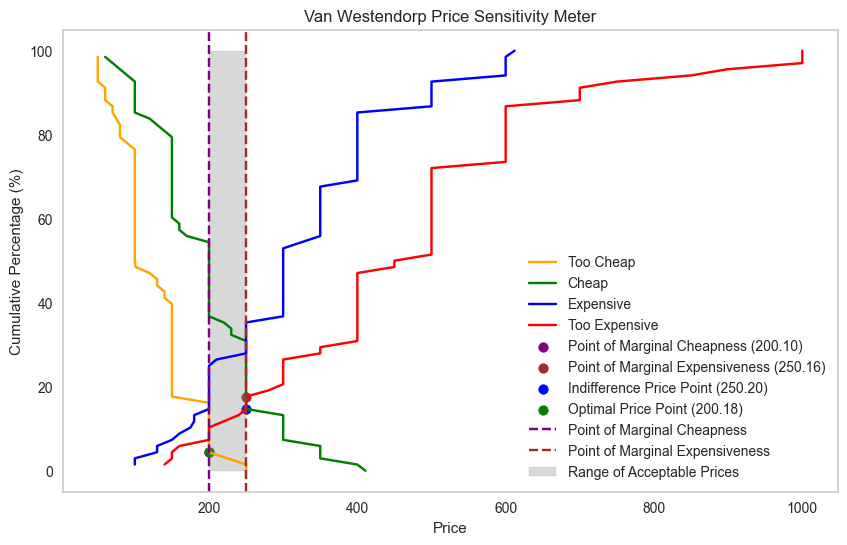

Van Westendorp Analysis:
Point of Marginal Cheapness: 200.10
Point of Marginal Expensiveness: 250.16
Indifference Price Point: 250.20
Optimal Price Point: 200.18




In [755]:
van_westendorp_analysis(df_vw_clean)

### Cluster 1

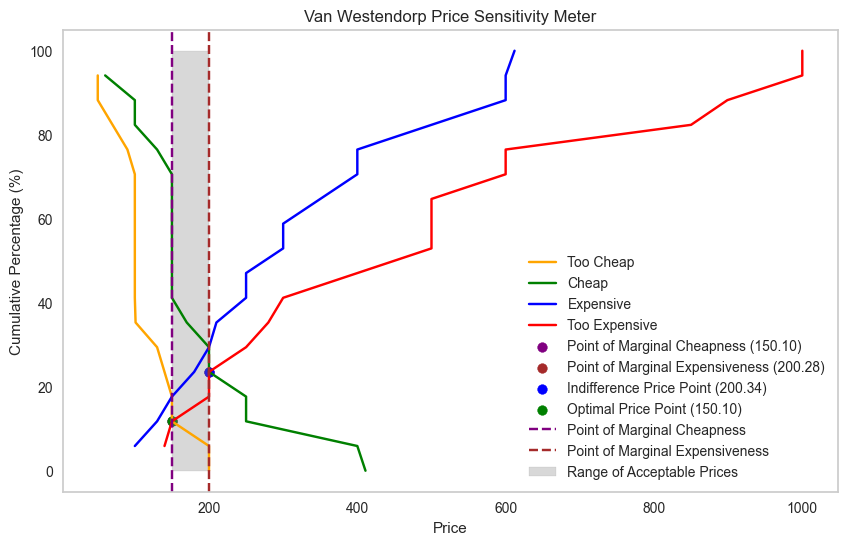

Van Westendorp Analysis:
Point of Marginal Cheapness: 150.10
Point of Marginal Expensiveness: 200.28
Indifference Price Point: 200.34
Optimal Price Point: 150.10




In [756]:
cluster_1 = df_vw_clean[df_vw_clean['cluster'] == 1]
van_westendorp_analysis(cluster_1)

In [757]:
cluster_1.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,17.000000,17.000000,17.000000,17.000000,17.0
mean,113.588235,186.529412,325.411765,492.294118,1.0
std,43.561822,95.798041,169.146039,295.136783,0.0
min,50.000000,60.000000,100.000000,140.000000,1.0
25%,100.000000,150.000000,200.000000,250.000000,1.0
50%,100.000000,150.000000,300.000000,500.000000,1.0
75%,140.000000,200.000000,400.000000,600.000000,1.0
max,200.000000,411.000000,612.000000,1000.000000,1.0


### Cluste 2

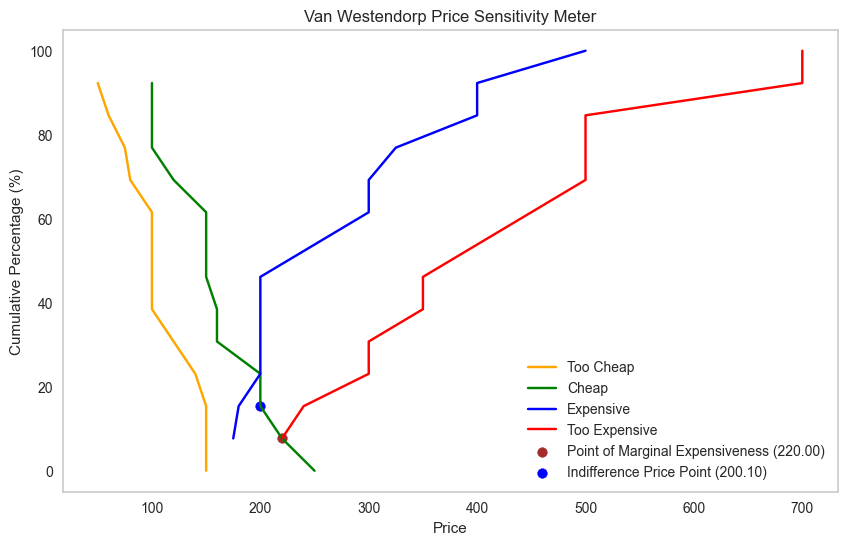

Van Westendorp Analysis:
Point of Marginal Cheapness: Not found
Point of Marginal Expensiveness: 220.00
Indifference Price Point: 200.10
Optimal Price Point: Not found




In [758]:
cluster_2 = df_vw_clean[df_vw_clean['cluster'] == 2]
van_westendorp_analysis(cluster_2)

In [759]:
cluster_2.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,13.000000,13.000000,13.000000,13.000000,13.0
mean,105.769231,158.461538,279.230769,423.846154,2.0
std,34.390294,47.931575,103.094741,154.948296,0.0
min,50.000000,100.000000,175.000000,220.000000,2.0
25%,80.000000,120.000000,200.000000,300.000000,2.0
50%,100.000000,150.000000,250.000000,400.000000,2.0
75%,140.000000,200.000000,325.000000,500.000000,2.0
max,150.000000,250.000000,500.000000,700.000000,2.0


### Cluster 3

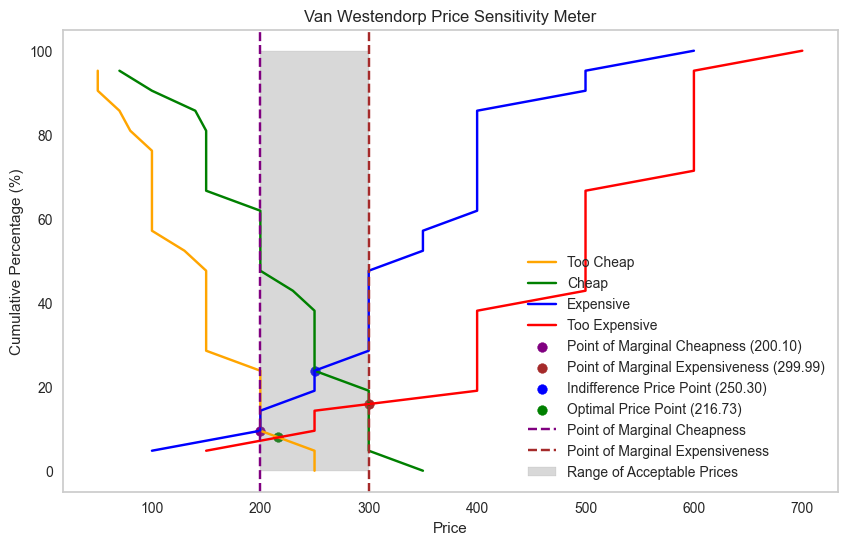

Van Westendorp Analysis:
Point of Marginal Cheapness: 200.10
Point of Marginal Expensiveness: 299.99
Indifference Price Point: 250.30
Optimal Price Point: 216.73




In [760]:
cluster_3 = df_vw_clean[df_vw_clean['cluster'] == 3]
van_westendorp_analysis(cluster_3)

In [761]:
cluster_3.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,21.000000,21.000000,21.000000,21.000000,21.0
mean,139.523810,213.809524,342.857143,473.809524,3.0
std,59.956333,74.126661,114.330348,138.400729,0.0
min,50.000000,70.000000,100.000000,150.000000,3.0
25%,100.000000,150.000000,300.000000,400.000000,3.0
50%,150.000000,200.000000,350.000000,500.000000,3.0
75%,200.000000,250.000000,400.000000,600.000000,3.0
max,250.000000,350.000000,600.000000,700.000000,3.0


### Cluster 4

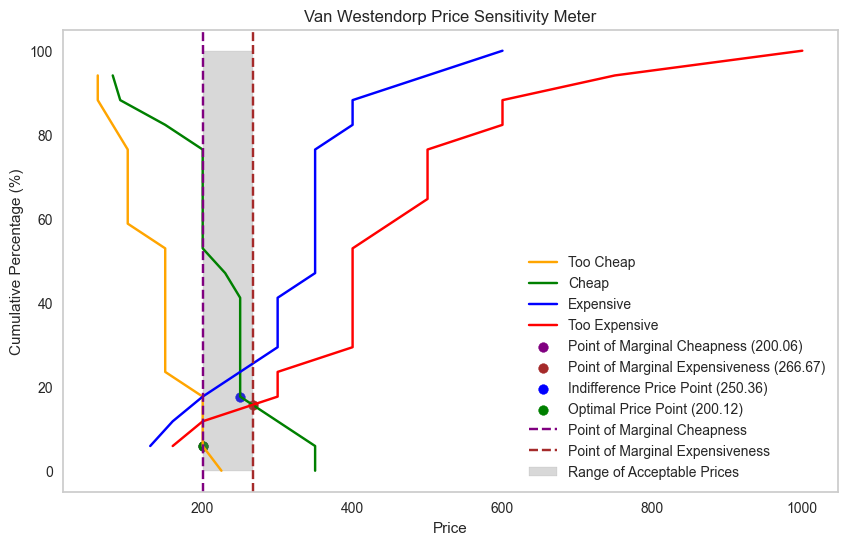

Van Westendorp Analysis:
Point of Marginal Cheapness: 200.06
Point of Marginal Expensiveness: 266.67
Indifference Price Point: 250.36
Optimal Price Point: 200.12




In [762]:
cluster_4 = df_vw_clean[df_vw_clean['cluster'] == 4]
van_westendorp_analysis(cluster_4)

In [763]:
cluster_4.describe()

,too_cheap,cheap,expensive,too_expensive,cluster
count,17.000000,17.000000,17.000000,17.000000,17.0
mean,136.764706,223.529412,331.764706,462.352941,4.0
std,50.773430,74.157027,114.249469,201.013974,0.0
min,60.000000,80.000000,130.000000,160.000000,4.0
25%,100.000000,200.000000,300.000000,400.000000,4.0
50%,150.000000,230.000000,350.000000,400.000000,4.0
75%,150.000000,250.000000,350.000000,500.000000,4.0
max,225.000000,350.000000,600.000000,1000.000000,4.0


# Predictive Model

In [764]:
import statsmodels.formula.api as smf

## Data preparation

In [858]:
df_predictive_model = df[['define_accommodation', 'accommodation_search', 'less_crowded_willingness', 'extra_travel_time',
                          'city_tour_type', 'architectural_interest', 'eating_preference',
                          'restaurant_choice', 'natural_environment_type', 'age_group', 'gender', 'residence', 'occupation']]

In [859]:
df_predictive_model['define_accommodation'] = df_predictive_model['define_accommodation'].replace({
    "…book in advance during the planning phase (reservar con tiempo durante la planificación)": 1,
    "…book at the last minute (reservar a último momento)": 2,
    "…book directly at the destination (reservar directamente en destino)": 3})

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\3256519308.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['define_accommodation'] = df_predictive_model['define_accommodation'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\3256519308.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['define_accommodation'] = df_predictive_model['define_accommodation'].replace({


In [860]:
# Replace time with average of the range
df_predictive_model['extra_travel_time'] = df_predictive_model['extra_travel_time'].replace({
    "Up to 30 minutes (Hasta 30 minutos)": 0.5,
    "1–2 hours (1-2 horas)": 1.5,
    "3–4 hours (3-4 horas)": 3.5,
    "More than 4 hours (Más de 4 horas)": 4.5,
    "I wouldn’t travel longer for that reason (No viajaría más por esa razón)": 0})

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\2522929736.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['extra_travel_time'] = df_predictive_model['extra_travel_time'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\2522929736.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['extra_travel_time'] = df_predictive_model['extra_travel_time'].replace({


In [861]:
# Replace city tour with numbers
df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].replace({
    "Guided walking tour (Tour guiado a pie)": 1,
    "Private tour (Tour privado)": 2,
    "Guided bicycle tour\xa0(Tour guiado en bicicleta)": 3,
    "Tourist train (Tren turístico)": 4,
    "": 0})

df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].fillna(0)

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\376882784.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\376882784.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['city_tour_type'] = df_predictive_model['city_tour_type'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\376882784.py:9: SettingWithCopyWarning: 
A value is trying to be set on a 

In [862]:
# Replace no city tour with numbers
df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].replace({
    "In the historic center (En el centro histórico)": 1,
    "Near my accommodation\xa0(Cerca de mi alojamiento)": 2,
    "In tourist areas (En zonas turísticas)": 3,
    "In less crowded, local neighborhoods (En barrios locales menos concurridos)": 4,
    "It doesn’t matter to me (Me da lo mismo)": 0,
    "": 0})

df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].fillna(0)

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\3036125505.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\3036125505.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['eating_preference'] = df_predictive_model['eating_preference'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\3036125505.py:10: SettingWithCopyWarning: 
A value is trying

In [863]:
# Replace no city tour with numbers
df_predictive_model['age_group'] = df_predictive_model['age_group'].replace({
    "<18": 1,
    "18-25": 2,
    "26-35": 3,
    "36-45": 4,
    "46-55": 5,
    ">55": 6})

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\1230033683.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['age_group'] = df_predictive_model['age_group'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\1230033683.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['age_group'] = df_predictive_model['age_group'].replace({


In [864]:
# Replace gender with number
df_predictive_model['gender'] = df_predictive_model['gender'].replace({
    "Male (Masculino)": 1,
    "Female (Femenino)": 0})

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\983272949.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['gender'] = df_predictive_model['gender'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\983272949.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['gender'] = df_predictive_model['gender'].replace({


In [865]:
# Replace with numbers

df_predictive_model['residence'] = df_predictive_model['residence'].replace({
    "Italy (Italia)": 1,
    "Europe, excluding Italy\xa0(Europa, sin contar Italia)": 2,
    "Asia": 3,
    "Africa": 4,
    "Oceania": 5,
    "North America (América del Norte)": 6,
    "Central America (América Central)": 7,
    "South America (América del Sur)": 8})

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\2380313427.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['residence'] = df_predictive_model['residence'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\2380313427.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['residence'] = df_predictive_model['residence'].replace({


In [866]:
# Replace with numbers
df_predictive_model['occupation'] = df_predictive_model['occupation'].replace({
    "Employed\xa0(Empleado/a)": 1,
    "Self-employed (Independiente)": 2,
    "Student (Estudiante)": 3,
    "Retired (Jubilado)": 4,
    "Unemployed\xa0(Desempleado)": 5})

C:\Users\franc\AppData\Local\Temp\ipykernel_35688\77980898.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_predictive_model['occupation'] = df_predictive_model['occupation'].replace({
C:\Users\franc\AppData\Local\Temp\ipykernel_35688\77980898.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_predictive_model['occupation'] = df_predictive_model['occupation'].replace({


In [867]:
# Separate answers into columns

def mult_answers(row):
    option = [a.strip() for a in str(row).split(";") if a.strip()]
    return {a: 1 for a in option}

def answer_title(df, column_name):
    expanded = df[column_name].apply(mult_answers)
    expanded = pd.DataFrame(expanded.tolist()).fillna(0).astype(int)
    expanded.columns = [f"{col} ({column_name})" for col in expanded.columns]
    return expanded

# Accommodation Search
accommodation_search = answer_title(df_predictive_model, "accommodation_search")

# No City Tour
architectural_interest = answer_title(df_predictive_model, "architectural_interest")

# restaurant_choice
restaurant_choice = answer_title(df_predictive_model, "restaurant_choice")

# natural_environment_type
natural_environment_type = answer_title(df_predictive_model, "natural_environment_type")

# Drop original columns
df_predictive_model = df_predictive_model.drop(columns=["accommodation_search", "architectural_interest", "restaurant_choice",
                                                        "natural_environment_type"])

In [868]:
df_predictive_model = pd.concat([
    df_predictive_model,
    accommodation_search,
    architectural_interest,
    restaurant_choice,
    natural_environment_type
], axis=1)

In [869]:
# Adding clusters

df_predictive_model["cluster"] = df_clustering["cluster"]

In [870]:
# Drop useless column

df_predictive_model = df_predictive_model.drop(columns=["nan (architectural_interest)"])

In [871]:
df_predictive_model.to_excel("table_for_predictive.xlsx")

In [879]:
df_predictive_model.columns = [
    "define_accommodation",
    "less_crowded_willingness",
    "extra_travel_time",
    "city_tour_type",
    "eating_preference",
    "age_group",
    "gender",
    "residence",
    "occupation",
    "Booking (accommodation_search)",
    "Airbnb (accommodation_search)",
    "Google (accommodation_search)",
    "Hotels (accommodation_search)",
    "Travel agencies (accommodation_search)",
    "Personal recommendation (accommodation_search)",
    "Social media (accommodation_search)",
    "ChatGPT and google maps (accommodation_search)",
    "Medieval architecture (architectural_interest)",
    "Historical squares and public spaces (architectural_interest)",
    "Museums and cultural centers (architectural_interest)",
    "Renaissance and Baroque palaces (architectural_interest)",
    "Religious buildings (architectural_interest)",
    "Modern or contemporary architecture (architectural_interest)",
    "I decide while walking by (restaurant_choice)",
    "Based on personal recommendations (restaurant_choice)",
    "Based on online reviews (restaurant_choice)",
    "Based on location (restaurant_choice)",
    "I search and book in advance (restaurant_choice)",
    "Based on recommendations I see on social media (restaurant_choice)",
    "I look for specific experiences or foods (restaurant_choice)",
    "Michelin Guide (restaurant_choice)",
    "Beach (natural_environment_type)",
    "Natural parks (natural_environment_type)",
    "Mountains (natural_environment_type)",
    "Lake/Rivers (natural_environment_type)",
    "El mar, pero no necesariamente playa (natural_environment_type)",
    "Cities with históricas heritage (natural_environment_type)",
    "cluster"
]

ValueError: Length mismatch: Expected axis has 35 elements, new values have 38 elements

In [880]:
# Group other answers, as they are not too much
def combine_columns(df, new_name, cols):
    df[new_name] = df[cols].max(axis=1).astype(int)
    df.drop(columns=cols, inplace=True)

# accommodation_search search
combine_columns(df_predictive_model,"Others (accommodation_search)", ["ChatGPT and google maps (accommodation_search)"])

# restaurant_choice
combine_columns(df_predictive_model,"Others (restaurant_choice)",
    [
        "Based on recommendations I see on social media (restaurant_choice)",
        "I look for specific experiences or foods (restaurant_choice)",
        "Michelin Guide (restaurant_choice)"
    ]
)

# natural_environment_type
combine_columns(df_predictive_model,"Others (natural_environment_type)",
    [
        "El mar, pero no necesariamente playa (natural_environment_type)",
        "Cities with históricas heritage (natural_environment_type)"
    ]
)

KeyError: "None of [Index(['ChatGPT and google maps (accommodation_search)'], dtype='object')] are in the [columns]"

In [ ]:
formula = """
cluster ~ define_accommodation
+ less_crowded_willingness
+ extra_travel_time
+ city_tour_type
+ eating_preference
+ age_group
+ gender
+ residence
+ occupation
"""

In [ ]:
+ Q("Booking (accommodation_search)")
+ Q("Airbnb (accommodation_search)")
+ Q("Google (accommodation_search)")
+ Q("Hotels (accommodation_search)")
+ Q("Travel agencies (accommodation_search)")
+ Q("Personal recommendation (accommodation_search)")
+ Q("Social media (accommodation_search)")
+ Q("Others (accommodation_search)")
+ Q("Medieval architecture (architectural_interest)")
+ Q("Historical squares and public spaces (architectural_interest)")
+ Q("Museums and cultural centers (architectural_interest)")
+ Q("Renaissance and Baroque palaces (architectural_interest)")
+ Q("Religious buildings (architectural_interest)")
+ Q("Modern or contemporary architecture (architectural_interest)")
+ Q("I decide while walking by (restaurant_choice)")
+ Q("Based on personal recommendations (restaurant_choice)")
+ Q("Based on online reviews (restaurant_choice)")
+ Q("Based on location (restaurant_choice)")
+ Q("I search and book in advance (restaurant_choice)")
+ Q("Others (restaurant_choice)")
+ Q("Beach (natural_environment_type)")
+ Q("Natural parks (natural_environment_type)")
+ Q("Mountains (natural_environment_type)")
+ Q("Lake/Rivers (natural_environment_type)")
+ Q("Others (natural_environment_type)")

In [888]:
modelo = smf.mnlogit(formula=formula, data=df_predictive_model).fit()
modelo.summary()

Optimization terminated successfully.
         Current function value: 1.268370
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                          MNLogit Regression Results                          
==============================================================================
Dep. Variable:                cluster   No. Observations:                  122
Model:                        MNLogit   Df Residuals:                      101
Method:                           MLE   Df Model:                           18
Date:                Thu, 23 Oct 2025   Pseudo R-squ.:                 0.07280
Time:                        12:07:19   Log-Likelihood:                -154.74
converged:                       True   LL-Null:                       -166.89
Covariance Type:            nonrobust   LLR p-value:                    0.1455
============================================================================================
               cluster=2       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -2.6079      1.832     -1.423      0.155      -6.199       0.983
define_accommodation         0.3285      0.787      0.417      0.676      -1.215       1.872
age_group                    0.5905      0.274      2.159      0.031       0.054       1.127
gender                      -0.2820      0.602     -0.468      0.640      -1.462       0.898
residence                    0.1112      0.106      1.052      0.293      -0.096       0.318
occupation                   0.2450      0.316      0.776      0.438      -0.374       0.864
less_crowded_willingness    -0.2480      0.298     -0.833      0.405      -0.831       0.335
--------------------------------------------------------------------------------------------
               cluster=3       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -0.1494      1.633     -0.092      0.927      -3.350       3.051
define_accommodation         0.0489      0.777      0.063      0.950      -1.473       1.571
age_group                    0.4537      0.261      1.736      0.083      -0.058       0.966
gender                      -0.9471      0.548     -1.729      0.084      -2.021       0.127
residence                   -0.0014      0.096     -0.015      0.988      -0.189       0.186
occupation                   0.1332      0.287      0.464      0.642      -0.429       0.695
less_crowded_willingness    -0.3251      0.264     -1.231      0.218      -0.843       0.192
--------------------------------------------------------------------------------------------
               cluster=4       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -2.9384      1.670     -1.759      0.079      -6.212       0.335
define_accommodation         0.1118      0.698      0.160      0.873      -1.256       1.479
age_group                    0.4411      0.251      1.757      0.079      -0.051       0.933
gender                      -0.1748      0.521     -0.336      0.737      -1.195       0.846
residence                    0.0386      0.092      0.420      0.675      -0.142       0.219
occupation                   0.2408      0.273      0.881      0.378      -0.295       0.776
less_crowded_willingness     0.3377      0.262      1.290      0.197      -0.175       0.851
============================================================================================
"""